In [1]:
# Autoload modules
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters, ProteinFoldingResult
from vqe import VQEC, VQECOpt
from qiskit.circuit.library import RealAmplitudes, EfficientSU2, TwoLocal
from qiskit.primitives import Sampler, Estimator
# from qiskit_aer.primitives import Estimator, Sampler
from qiskit_aer import AerSimulator
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient, LinCombEstimatorGradient, LinCombQGT, SPSAEstimatorGradient, FiniteDiffEstimatorGradient
import numpy as np
import matplotlib.pyplot as plt
from qufold.execution_utils.measurements import _evaluate_sparsepauli
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit

In [3]:
from vqe_optimization_goldstein import VQECOpt_goldstein 

In [4]:
from commutator_funcs import *
from dcd_ansatz import *

## VQEC workflow

In [5]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)
    print(mj_interaction.calculate_energy_matrix(main_seq))

    penalty_back = 50
    penalty_redun = 50
    # penalty_olap = 50

    penalty_terms = PenaltyParameters(penalty_back, penalty_redun)

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(peptide, mj_interaction, penalty_terms)

    return protein_folding_problem

In [6]:
def classify_amino_acids(sequence):
    hydrophobic = set('GAVLIPFMW')
    return ''.join('H' if amino in hydrophobic else 'P' for amino in sequence)

In [7]:
print(classify_amino_acids("LFLF"))

HHHH


In [8]:
main_seq_4 = "LFLF" # 6MVZ ("LFLF")YYDPETGTWY
protein_folding_problem = build_pf(classify_amino_acids(main_seq_4), 'hp_matrix')
qubit_op = protein_folding_problem.qubit_op()
print(f"Number of qubits: {qubit_op.num_qubits}")
print(f"Number of terms: {len(qubit_op)}")

[[ 0. -1. -1. -1.]
 [ 0.  0. -1. -1.]
 [ 0.  0.  0. -1.]
 [ 0.  0.  0.  0.]]
Number of qubits: 9
Number of terms: 107


In [9]:
from qiskit.quantum_info import SparsePauliOp
from collections import Counter

def analyze_pauli_terms(pauli_op: SparsePauliOp):
    # Extract labels from the Pauli operator
    labels = pauli_op.paulis.to_labels()
    
    # Initialize a Counter to store occurrences of each Pauli term type
    term_types = Counter()
    
    # Iterate over each label and process
    # Skip the sorting to keep 'XZ' and 'ZX' distinct
    for label in labels:
        # Remove identity matrices, keep the order of non-identity Pauli matrices
        normalized_label = label.replace('I', '')
        if normalized_label == '':
            normalized_label = 'I'  # Include identity as a term if all are 'I'
        term_types[normalized_label] += 1
    
    # Return a dictionary of term types with their counts
    return dict(term_types)


In [10]:
dcd_hamiltonian = calculate_commutator(qubit_op, True, 1)
analyze_pauli_terms(dcd_hamiltonian)

{'Y': 8, 'YZ': 20, 'ZY': 20}

In [11]:
from qiskit.quantum_info import SparsePauliOp, Pauli

def select_terms(dcd_hamiltonian, term_analysis, num_qubits):
    # Extract labels and coefficients
    labels = dcd_hamiltonian.paulis.to_labels()
    coeffs = dcd_hamiltonian.coeffs
    
    # Determine the weight-2 term with the lowest count
    lowest_count = float('inf')
    lowest_term_type = None
    for term, count in term_analysis.items():
        if len(term) == 2 and count < lowest_count:
            lowest_count = count
            lowest_term_type = term

    # Initialize a list to collect the selected terms with their coefficients
    selected_terms = []
    
    # Filter the terms based on the analysis
    for label, coeff in zip(labels, coeffs):
        normalized_label = ''.join(sorted(label.replace('I', '')))
        
        # Select weight-1 terms where the count matches the number of qubits
        if normalized_label in term_analysis and len(normalized_label) == 1 and term_analysis[normalized_label] == num_qubits:
            selected_terms.append((label, coeff))
        
        # Select weight-2 terms of the type with the lowest count
        elif normalized_label == lowest_term_type:
            selected_terms.append((label, coeff))

    # Return a new SparsePauliOp with the selected terms
    return SparsePauliOp.from_list(selected_terms)


In [12]:
optimal_dcd_selection = select_terms(dcd_hamiltonian, analyze_pauli_terms(dcd_hamiltonian), qubit_op.num_qubits)

In [13]:
cd_ansatz = dig_count_ansatz(optimal_dcd_selection)

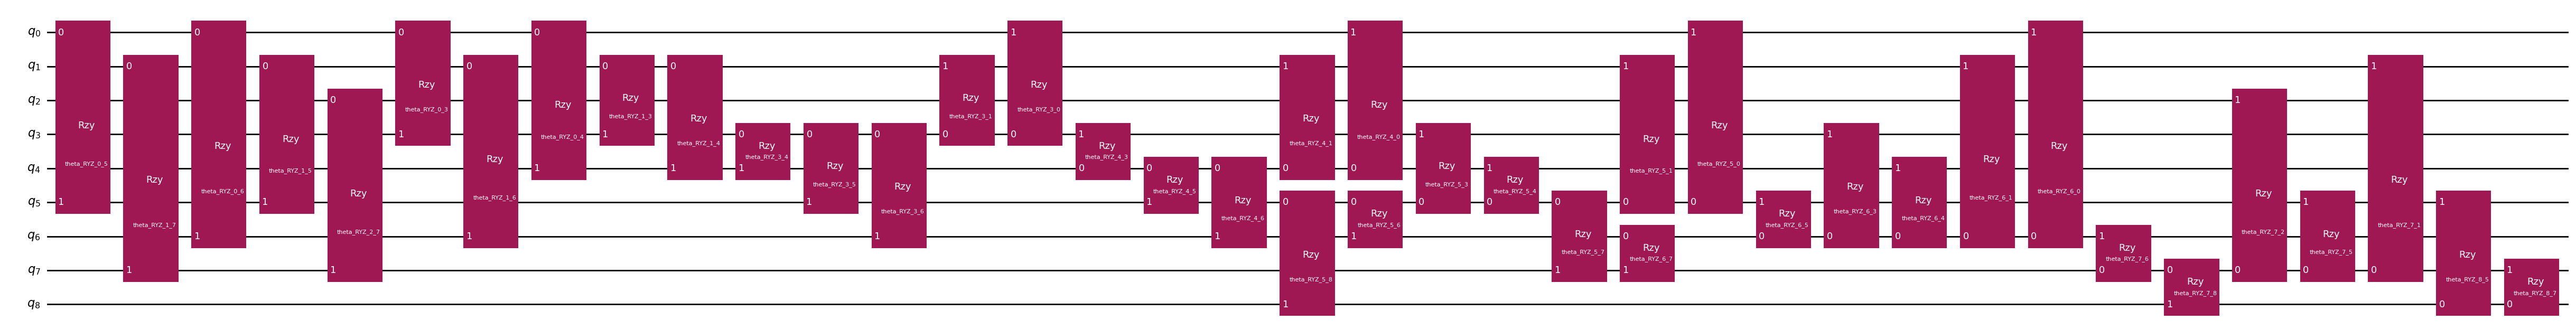

In [14]:
cd_ansatz.draw('mpl', fold=-1)

In [15]:
bead_pairs, olap_constr_ops = protein_folding_problem.olap_constr_ops()
print(f"Number of overlap constraints: {len(olap_constr_ops)}")
print(f"Number of qubits: {olap_constr_ops[0].num_qubits}")

Number of overlap constraints: 1
Number of qubits: 9


In [16]:
# ansatz_ra = RealAmplitudes(qubit_op.num_qubits, skip_final_rotation_layer=False)

ansatz_su2 = EfficientSU2(qubit_op.num_qubits, skip_final_rotation_layer=False)

# ansatz_2local = TwoLocal(qubit_op.num_qubits, reps=3, rotation_blocks=['rz', 'rx'], entanglement_blocks= 'cx', entanglement='full', skip_final_rotation_layer=False)

In [17]:
# ansatz_2local.decompose().draw('mpl', fold=-1)

In [17]:
estimator = Estimator()
# estimator = Estimator(backend_options={'method': 'matrix_product_state'})
gradient_lincomb = LinCombEstimatorGradient(estimator=estimator)

C:\Users\8J6010897\AppData\Local\Temp\ipykernel_27912\81681451.py:1: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator()


In [18]:
# Define the successful omega and theta values to be tested
successful_pairs = [
    {'omega': 0.01, 'theta': 0.6000000000000001},
    {'omega': 0.05333333333333334, 'theta': 0.2666666666666667},
    {'omega': 0.14, 'theta': 0.4},
    {'omega': 0.14, 'theta': 0.5333333333333334},
    {'omega': 0.22666666666666668, 'theta': 0.2666666666666667},
    {'omega': 0.27, 'theta': 0.7333333333333334}
]

# List to store the final results
vqec_success_results = []

# Define the target bitstring
target_bitstring = "111111110"

# Iterate over the successful pairs of omega and theta
for pair in successful_pairs:
    omega = pair['omega']
    theta = pair['theta']
    
    # Track successful occurrences of the target bitstring for this pair
    success_count = 0
    
    for run in range(10):  # Run 10 trials for each pair
        print(f"Running VQEC with omega={omega}, theta={theta}, trial {run + 1}")
        
        # Initialize the VQECOpt_goldstein with current omega and theta values
        vqec_lincomb = VQECOpt_goldstein(
            primal_perturb_step=0.05,
            dual_perturb_step=0.05,
            omega=omega,
            theta=theta,
            qubit_op=qubit_op,
            constr_ops=olap_constr_ops,
            ansatz=cd_ansatz,
            estimator=estimator,
            gradient=gradient_lincomb,
            max_iter=200
        )

        # Run the optimization
        vqec_lincomb_result = vqec_lincomb.optimize_primal_dual()

        # Get the optimized ansatz and sample from it
        full_circ = vqec_lincomb_result.ansatz.copy()
        full_circ.measure_all()
        
        # Initialize the sampler
        sampler = Sampler(options={"shots": 10000})
        sampler_result = sampler.run(circuits=[full_circ], parameter_values=vqec_lincomb_result.optimal_primal_vars).result()
        
        # Get the quasi-probabilities and sort them
        quasi_dist = sampler_result.quasi_dists[0].binary_probabilities()
        sorted_quasi_dist = dict(sorted(quasi_dist.items(), key=lambda item: item[1], reverse=True))

        # Check top 5 bitstrings and calculate energies
        bitstring_energies = {}
        found = False  # Flag to track if target bitstring is found
        for i, (sample, prob) in enumerate(sorted_quasi_dist.items()):
            if i >= 5:  # Only take the top 5
                break
            
            # Compute energy for the bitstring
            energy = _evaluate_sparsepauli(sample, qubit_op)
            bitstring_energies[sample] = energy
            
            # Check if the target bitstring is among the top 5
            if sample == target_bitstring:
                found = True
                print(f"Sample {i}: {sample} with probability {prob} and energy {energy}")
        
        # If the target bitstring is found, increase success count
        if found:
            success_count += 1
    
    # Store the result for this pair of omega and theta
    vqec_success_results.append({
        'omega': omega,
        'theta': theta,
        'success_count': success_count  # Track how many times the target bitstring was found
    })

# Print the final results for each pair
print("Final success counts for each omega and theta:")
for result in vqec_success_results:
    print(f"omega: {result['omega']}, theta: {result['theta']}, success count: {result['success_count']} out of 10")


Running VQEC with omega=0.01, theta=0.6000000000000001, trial 1


100%|██████████| 200/200 [03:28<00:00,  1.04s/it]
C:\Users\8J6010897\AppData\Local\Temp\ipykernel_27912\869101932.py:50: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler(options={"shots": 10000})


Running VQEC with omega=0.01, theta=0.6000000000000001, trial 2


100%|██████████| 200/200 [03:23<00:00,  1.02s/it]


Running VQEC with omega=0.01, theta=0.6000000000000001, trial 3


...

Goldstein test failed at iteration 199. Reducing step size.
Running VQEC with omega=0.27, theta=0.7333333333333334, trial 10


  9%|▉         | 18/200 [00:19<02:56,  1.03it/s]

Goldstein test failed at iteration 17. Reducing step size.


100%|██████████| 200/200 [03:34<00:00,  1.07s/it]

Final success counts for each omega and theta:
omega: 0.01, theta: 0.6000000000000001, success count: 0 out of 10
omega: 0.05333333333333334, theta: 0.2666666666666667, success count: 0 out of 10
omega: 0.14, theta: 0.4, success count: 0 out of 10
omega: 0.14, theta: 0.5333333333333334, success count: 2 out of 10
omega: 0.22666666666666668, theta: 0.2666666666666667, success count: 1 out of 10
omega: 0.27, theta: 0.7333333333333334, success count: 0 out of 10


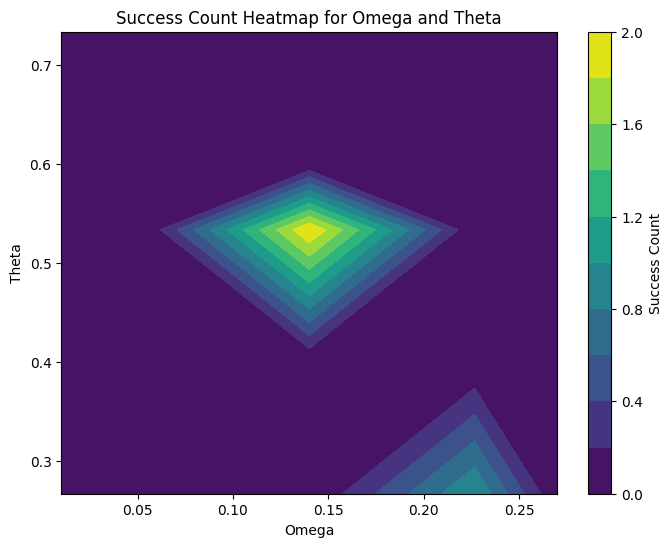

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming 'vqec_success_results' contains the results as described earlier
# Extract omega, theta, and success_count from the result data
omegas = [result['omega'] for result in vqec_success_results]
thetas = [result['theta'] for result in vqec_success_results]
success_counts = [result['success_count'] for result in vqec_success_results]

# Convert the lists into numpy arrays for plotting
omega_vals = np.array(omegas)
theta_vals = np.array(thetas)
success_vals = np.array(success_counts)

# Create a grid for the omega and theta values for plotting
omega_unique = np.unique(omega_vals)
theta_unique = np.unique(theta_vals)
omega_grid, theta_grid = np.meshgrid(omega_unique, theta_unique)

# Create an empty grid for success counts and fill it with values
success_grid = np.zeros_like(omega_grid, dtype=np.float64)

# Populate the success grid with the success counts
for i in range(len(omega_vals)):
    # Find the correct position in the grid for each omega/theta pair
    omega_idx = np.where(omega_unique == omega_vals[i])[0][0]
    theta_idx = np.where(theta_unique == theta_vals[i])[0][0]
    success_grid[theta_idx, omega_idx] = success_vals[i]

# Plot the heatmap
plt.figure(figsize=(8, 6))
plt.contourf(omega_grid, theta_grid, success_grid, levels=10, cmap='viridis')
plt.colorbar(label='Success Count')

# Add labels and title
plt.title('Success Count Heatmap for Omega and Theta')
plt.xlabel('Omega')
plt.ylabel('Theta')

# Show the plot
plt.show()


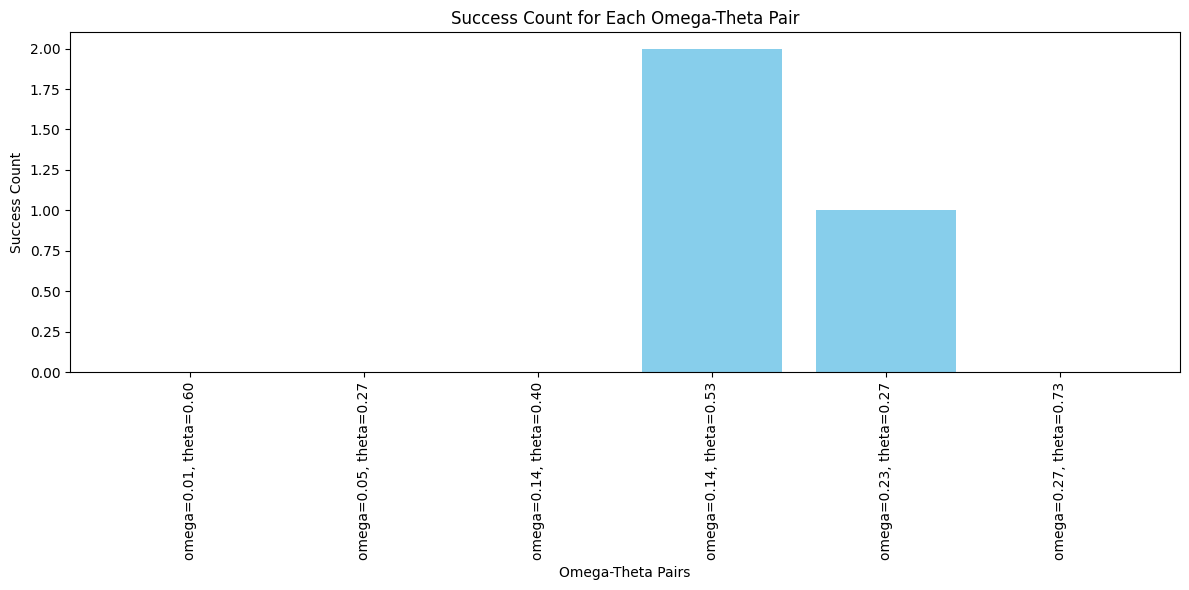

In [20]:
import matplotlib.pyplot as plt

# Assuming 'vqec_success_results' contains the results as described earlier
# Extract omega, theta, and success_count from the result data
omegas = [result['omega'] for result in vqec_success_results]
thetas = [result['theta'] for result in vqec_success_results]
success_counts = [result['success_count'] for result in vqec_success_results]

# Combine omega and theta into a label for each pair
omega_theta_pairs = [f"omega={omega:.2f}, theta={theta:.2f}" for omega, theta in zip(omegas, thetas)]

# Create a bar plot
plt.figure(figsize=(12, 6))
plt.bar(omega_theta_pairs, success_counts, color='skyblue')

# Add labels and title
plt.title('Success Count for Each Omega-Theta Pair')
plt.xlabel('Omega-Theta Pairs')
plt.ylabel('Success Count')

# Rotate x-axis labels for better visibility
plt.xticks(rotation=90)

# Show the plot
plt.tight_layout()
plt.show()


In [24]:
# Optimal solution for LFLF
print(_evaluate_sparsepauli("111111110", qubit_op))

print(_evaluate_sparsepauli("001001110", qubit_op))

-3.0
-1.0
